In [1]:
#importing libraries
import pandas as pd
import ast
import seaborn as sns
import numpy as np
from datasets import load_dataset
import matplotlib.pyplot as plt

#loading dataset
dataset=load_dataset('lukebarousse/data_jobs')
df=dataset['train'].to_pandas() # converting data into pandas 

# data clean up
df['job_posted_date']=pd.to_datetime(df['job_posted_date'])# converting datatype from object to date time

# safely converts a string representation of a Python object into an actual Python object
df['job_skills'] = df['job_skills'].apply(
    lambda x: ast.literal_eval(x) if pd.notna(x) else x
)


In [4]:
df_DA_US=df[(df['job_country']=='United States')&(df['job_title']=='Data Analyst')].copy() # creating a new data frame df_DA_US  and making copy of it 


In [12]:
df_DA_US['job_posted_month_no']=df_DA_US['job_posted_date'].dt.month

In [13]:
df_DA_US_explode=df_DA_US.explode('job_skills')

In [14]:
df_DA_US_pivot=df_DA_US_explode.pivot_table(index='job_posted_month_no',columns='job_skills',aggfunc='size',fill_value=0)

In [16]:
df_DA_US_pivot.loc['Total'] = df_DA_US_pivot.sum()

In [17]:
# sort column by total frequency
df_DA_US_pivot = df_DA_US_pivot[
    df_DA_US_pivot.loc['Total']
    .sort_values(ascending=False)
    .index
]

<Axes: xlabel='job_posted_month_no'>

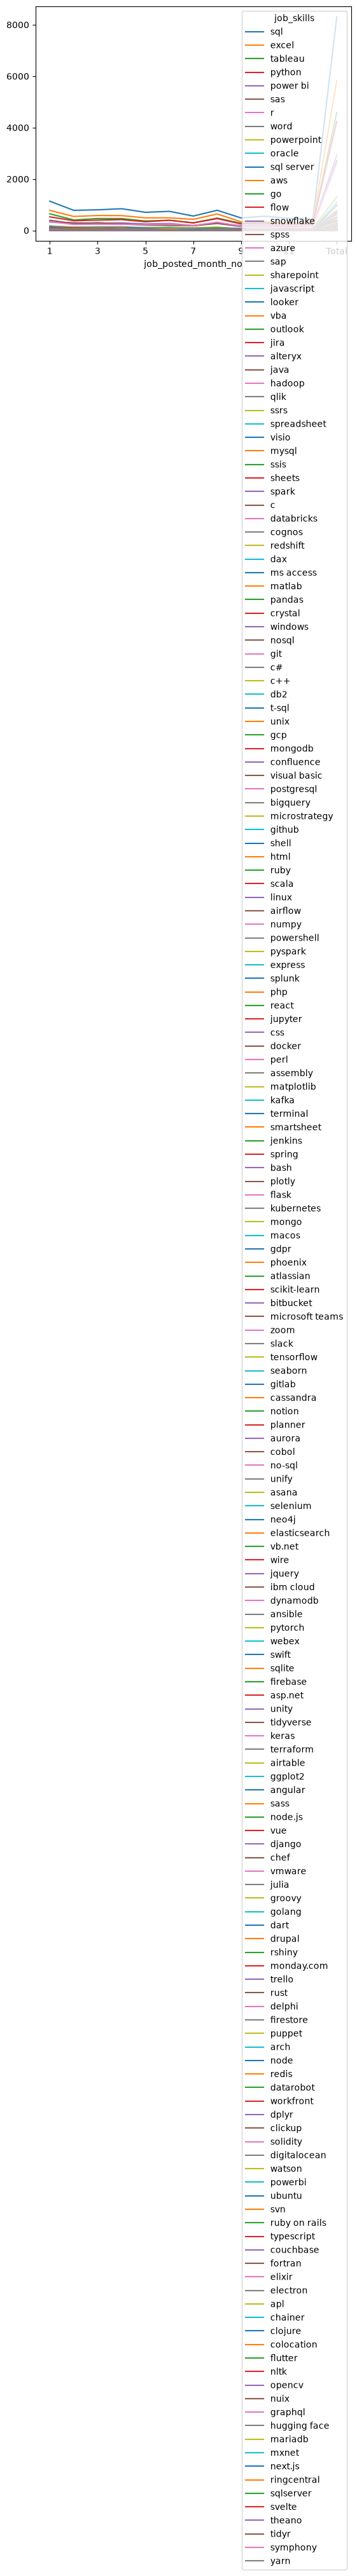

In [20]:
df_DA_US_pivot.plot(kind='line')

In [22]:
DA_totals=df_DA_US.groupby('job_posted_month_no').size()

In [23]:
df_DA_US_perc=df_DA_US_pivot.div(DA_totals/100,axis=0)
df_DA_US_perc

job_skills,sql,excel,tableau,python,power bi,sas,r,word,powerpoint,oracle,...,mariadb,mxnet,next.js,ringcentral,sqlserver,svelte,theano,tidyr,symphony,yarn
job_posted_month_no,,,,,,,,,,,,,,,,,,,,,
1,62.665198,43.006608,35.572687,29.129956,17.951542,21.696035,18.612335,9.306167,9.691630,9.030837,...,0.000000,0.000000,0.000000,0.055066,0.000000,0.000000,0.000000,0.0000,0.000000,0.000000
2,60.903427,42.367601,31.775701,29.439252,23.520249,21.028037,18.146417,9.968847,10.124611,7.710280,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0000,0.000000,0.000000
3,58.883994,42.584435,33.994126,29.368576,20.337739,22.026432,17.694567,10.425844,9.324523,7.856094,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0000,0.000000,0.000000
4,61.723886,42.147553,33.747261,30.752374,21.329438,18.845873,17.384953,10.445581,9.715121,8.911614,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0000,0.000000,0.000000
5,61.072664,42.387543,31.747405,29.065744,21.712803,17.820069,18.944637,7.958478,10.294118,8.477509,...,0.086505,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0000,0.000000,0.000000
6,61.474731,40.679370,32.725766,32.808616,22.535211,16.735708,20.878210,10.439105,9.610605,8.202154,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0000,0.000000,0.000000
7,58.638743,45.130890,30.994764,30.575916,19.895288,19.057592,19.685864,10.575916,10.575916,6.492147,...,0.000000,0.000000,0.104712,0.000000,0.104712,0.000000,0.000000,0.0000,0.000000,0.104712
8,55.445545,45.332390,33.946252,32.531825,20.650636,19.236209,22.701556,7.920792,9.405941,6.930693,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0000,0.000000,0.000000
9,56.658879,39.252336,32.359813,29.556075,21.378505,17.523364,18.341121,7.593458,6.191589,7.827103,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0000,0.116822,0.000000


In [28]:
df_DA_US_perc.columns

Index(['job_posted_month', 'level_0', 'index', 'sql', 'excel', 'tableau',
       'python', 'power bi', 'sas', 'r',
       ...
       'mariadb', 'mxnet', 'next.js', 'ringcentral', 'sqlserver', 'svelte',
       'theano', 'tidyr', 'symphony', 'yarn'],
      dtype='str', name='job_skills', length=191)

In [ ]:
df_DA_US_perc = df_DA_US_perc.reset_index()

df_DA_US_perc['job_posted_month'] = pd.to_datetime(
    df_DA_US_perc['job_posted_month_no'],
    format='%m'
).dt.strftime('%b')

df_DA_US_perc = df_DA_US_perc.set_index('job_posted_month')
df_DA_US_perc = df_DA_US_perc.drop(columns='job_posted_month_no')


In [29]:
# Remove extra columns
df_DA_US_perc = df_DA_US_perc.drop(columns=['level_0', 'index'], errors='ignore')

# Set month as the index
df_DA_US_perc = df_DA_US_perc.set_index('job_posted_month')

df_DA_US_perc.head()

job_skills,sql,excel,tableau,python,power bi,sas,r,word,powerpoint,oracle,...,mariadb,mxnet,next.js,ringcentral,sqlserver,svelte,theano,tidyr,symphony,yarn
job_posted_month,,,,,,,,,,,,,,,,,,,,,
Jan,62.665198,43.006608,35.572687,29.129956,17.951542,21.696035,18.612335,9.306167,9.691630,9.030837,...,0.000000,0.0,0.0,0.055066,0.0,0.0,0.0,0.0,0.0,0.0
Feb,60.903427,42.367601,31.775701,29.439252,23.520249,21.028037,18.146417,9.968847,10.124611,7.710280,...,0.000000,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0
Mar,58.883994,42.584435,33.994126,29.368576,20.337739,22.026432,17.694567,10.425844,9.324523,7.856094,...,0.000000,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0
Apr,61.723886,42.147553,33.747261,30.752374,21.329438,18.845873,17.384953,10.445581,9.715121,8.911614,...,0.000000,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0
May,61.072664,42.387543,31.747405,29.065744,21.712803,17.820069,18.944637,7.958478,10.294118,8.477509,...,0.086505,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0


In [30]:
df_plot = df_DA_US_perc.iloc[:, :5]

In [49]:
df_DA_US_perc = df_DA_US_perc.drop(index='Total', errors='ignore')
df_plot = df_DA_US_perc.iloc[:, :5]

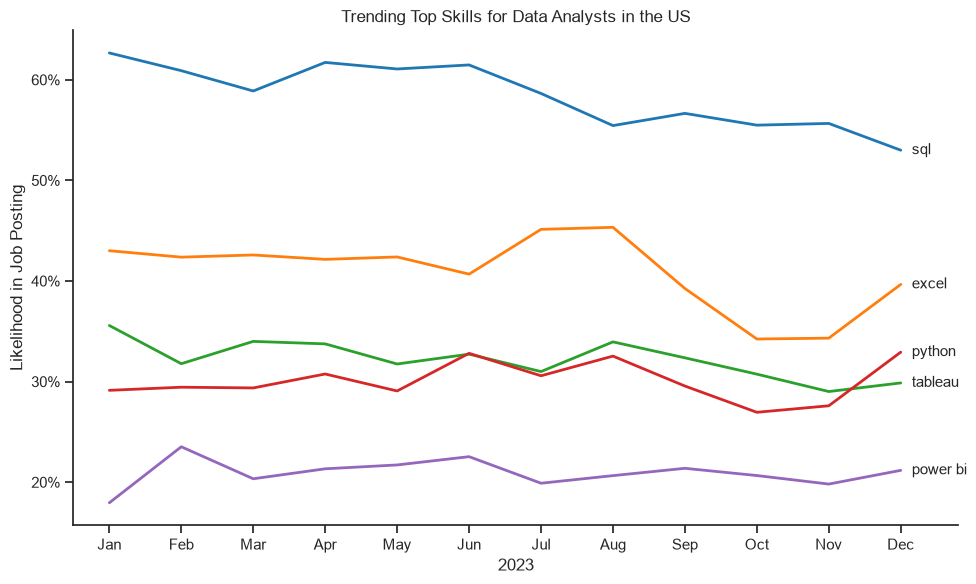

In [52]:
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import PercentFormatter

# Top 5 skills
df_plot = df_DA_US_perc.iloc[:, :5]

sns.set_theme(style="ticks")

fig, ax = plt.subplots(figsize=(10, 6))

sns.lineplot(
    data=df_plot,
    dashes=False,
    palette="tab10",
    linewidth=2,
    ax=ax
)

sns.despine()

ax.set_title("Trending Top Skills for Data Analysts in the US")
ax.set_xlabel("2023")
ax.set_ylabel("Likelihood in Job Posting")

# Format y-axis as percentages
ax.yaxis.set_major_formatter(PercentFormatter(decimals=0.1))

# Remove legend
if ax.get_legend() is not None:
    ax.get_legend().remove()

# Add a little space on the right
ax.set_xlim(-0.5, len(df_plot.index) - 0.2)

# Write skill names at the end of each line
for line, skill in zip(ax.lines, df_plot.columns):
    x = line.get_xdata()[-1]
    y = line.get_ydata()[-1]

    ax.annotate(
        skill,
        xy=(x, y),
        xytext=(8, 0),               # 8 points to the right
        textcoords="offset points",
        va="center",
        fontsize=11
    )

plt.tight_layout()
plt.show()

In [51]:
print(df_plot.index)

Index(['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct',
       'Nov', 'Dec'],
      dtype='str', name='job_posted_month')
